# Lab Final (Task-1)

## Name: Tasrif Nur Himel
## ID: 221-35-1078

### Course Code: DS422
### Section: B1
### Batch: 37

### Load Dataset From Kaggle

In [1]:
!pip install kagglehub[pandas-datasets]

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "airbnb/seattle",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

## 1.	Dataset Acquisition:

### Alternatve manually download from: https://www.kaggle.com/datasets/airbnb/seattle?select=listings.csv

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2.	Data Loading:

In [7]:
df = pd.read_csv("listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


##	Data Exploration:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   object 
 2   scrape_id                         3818 non-null   int64  
 3   last_scraped                      3818 non-null   object 
 4   name                              3818 non-null   object 
 5   summary                           3641 non-null   object 
 6   space                             3249 non-null   object 
 7   description                       3818 non-null   object 
 8   experiences_offered               3818 non-null   object 
 9   neighborhood_overview             2786 non-null   object 
 10  notes                             2212 non-null   object 
 11  transit                           2884 non-null   object 
 12  thumbn

In [9]:
df.isnull().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
name,0
...,...
cancellation_policy,0
require_guest_profile_picture,0
require_guest_phone_verification,0
calculated_host_listings_count,0


In [10]:
null_counts = df.isnull().sum().sort_values(ascending=False)
print(null_counts[null_counts > 0])

license                        3818
square_feet                    3721
monthly_price                  2301
security_deposit               1952
weekly_price                   1809
notes                          1606
neighborhood_overview          1032
cleaning_fee                   1030
transit                         934
host_about                      859
host_acceptance_rate            773
review_scores_accuracy          658
review_scores_checkin           658
review_scores_value             656
review_scores_location          655
review_scores_cleanliness       653
review_scores_communication     651
review_scores_rating            647
last_review                     627
first_review                    627
reviews_per_month               627
space                           569
host_response_rate              523
host_response_time              523
neighbourhood                   416
medium_url                      320
thumbnail_url                   320
xl_picture_url              

In [11]:
missing_cols = df.columns[df.isnull().sum() > 0].tolist()
print(missing_cols)

['summary', 'space', 'neighborhood_overview', 'notes', 'transit', 'thumbnail_url', 'medium_url', 'xl_picture_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'zipcode', 'property_type', 'bathrooms', 'bedrooms', 'beds', 'square_feet', 'weekly_price', 'monthly_price', 'security_deposit', 'cleaning_fee', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 'reviews_per_month']


## Data Preprocessing:

In [12]:
columns_to_keep = [
    'neighbourhood_group_cleansed','room_type','accommodates','bathrooms',
    'bedrooms','beds','minimum_nights','availability_365','number_of_reviews',
    'review_scores_rating','review_scores_value','reviews_per_month','amenities',
    'guests_included','maximum_nights','availability_30','price'
]

existing = [c for c in columns_to_keep if c in df.columns]
missing = [c for c in columns_to_keep if c not in df.columns]
df = df[existing].copy()

print("Kept columns:", existing)
print("Not found (ok to ignore):", missing)

Kept columns: ['neighbourhood_group_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_value', 'reviews_per_month', 'amenities', 'guests_included', 'maximum_nights', 'availability_30', 'price']
Not found (ok to ignore): []


In [13]:
df

,neighbourhood_group_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_value,reviews_per_month,amenities,guests_included,maximum_nights,availability_30,price
0,Queen Anne,Entire home/apt,4,1.0,1.0,1.0,1,346,207,95.0,10.0,4.07,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",2,365,14,$85.00
1,Queen Anne,Entire home/apt,4,1.0,1.0,1.0,2,291,43,96.0,10.0,1.48,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",1,90,13,$150.00
2,Queen Anne,Entire home/apt,11,4.5,5.0,7.0,4,220,20,97.0,10.0,1.15,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",10,30,1,$975.00
3,Queen Anne,Entire home/apt,3,1.0,0.0,2.0,1,143,0,NaN,NaN,NaN,"{Internet,""Wireless Internet"",Kitchen,""Indoor ...",1,1125,0,$100.00
4,Queen Anne,Entire home/apt,6,2.0,3.0,3.0,1,365,38,92.0,9.0,0.89,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",6,1125,30,$450.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,Other neighborhoods,Entire home/apt,6,2.0,3.0,3.0,3,32,1,80.0,8.0,0.30,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1125,18,$359.00
3814,Capitol Hill,Entire home/apt,4,1.0,1.0,2.0,2,273,2,100.0,10.0,2.00,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",3,29,6,$79.00
3815,Rainier Valley,Entire home/apt,2,1.0,1.0,1.0,1,88,0,NaN,NaN,NaN,"{""Cable TV"",""Wireless Internet"",Kitchen,""Free ...",2,7,29,$93.00
3816,Capitol Hill,Entire home/apt,2,1.0,0.0,1.0,3,179,0,NaN,NaN,NaN,"{TV,""Wireless Internet"",Kitchen,""Free Parking ...",1,1125,30,$99.00


In [14]:
df.info()
print("\nMissing per column:\n", df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   neighbourhood_group_cleansed  3818 non-null   object 
 1   room_type                     3818 non-null   object 
 2   accommodates                  3818 non-null   int64  
 3   bathrooms                     3802 non-null   float64
 4   bedrooms                      3812 non-null   float64
 5   beds                          3817 non-null   float64
 6   minimum_nights                3818 non-null   int64  
 7   availability_365              3818 non-null   int64  
 8   number_of_reviews             3818 non-null   int64  
 9   review_scores_rating          3171 non-null   float64
 10  review_scores_value           3162 non-null   float64
 11  reviews_per_month             3191 non-null   float64
 12  amenities                     3818 non-null   object 
 13  gue

### EDA and Feature Engineering

In [15]:
df['price'] = (
    df['price']
      .astype(str)
      .str.replace(r'[\$,]', '', regex=True)
      .replace('nan', np.nan)
      .astype(float)
)

print("Price summary:\n", df['price'].describe())

Price summary:
 count    3818.000000
mean      127.976166
std        90.250022
min        20.000000
25%        75.000000
50%       100.000000
75%       150.000000
max      1000.000000
Name: price, dtype: float64


In [16]:
for col in ['bathrooms','bedrooms','beds','review_scores_rating','review_scores_value']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if 'reviews_per_month' in df.columns:
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

if 'amenities' in df.columns:
    df['amenities'] = df['amenities'].fillna("[]")

print("Missing after fills:\n", df.isnull().sum().sort_values(ascending=False))

Missing after fills:
 neighbourhood_group_cleansed    0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
beds                            0
minimum_nights                  0
availability_365                0
number_of_reviews               0
review_scores_rating            0
review_scores_value             0
reviews_per_month               0
amenities                       0
guests_included                 0
maximum_nights                  0
availability_30                 0
price                           0
dtype: int64


### Visualzation

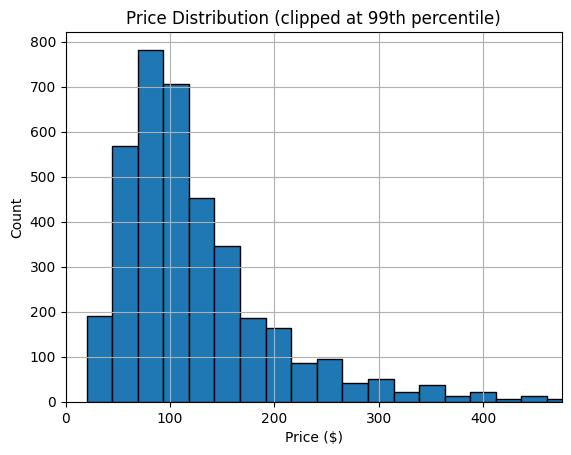

In [17]:
p99 = df['price'].quantile(0.99)
df['price'].hist(bins=40, edgecolor='black')
plt.title('Price Distribution (clipped at 99th percentile)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.xlim(0, p99)
plt.show()

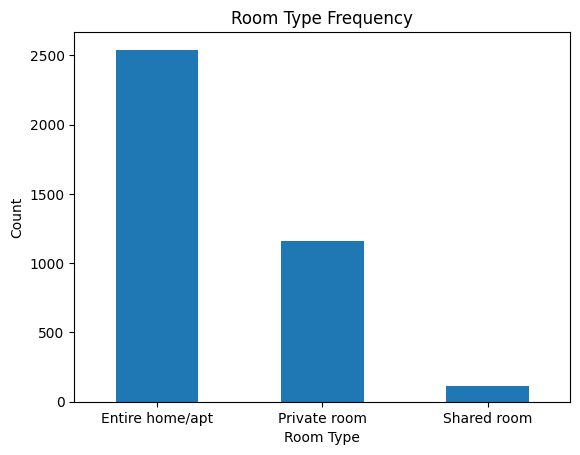

room_type
Entire home/apt    2541
Private room       1160
Shared room         117
Name: count, dtype: int64


In [18]:

ax = df['room_type'].value_counts().plot(kind='bar', rot=0)
ax.set_title('Room Type Frequency')
ax.set_xlabel('Room Type')
ax.set_ylabel('Count')
plt.show()

print(df['room_type'].value_counts())


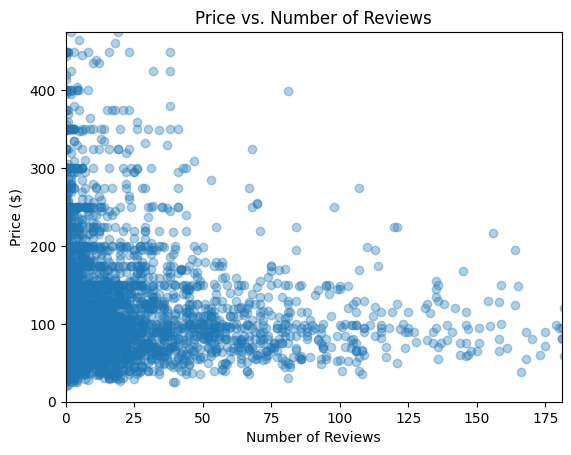

                   number_of_reviews     price
number_of_reviews           1.000000 -0.124695
price                      -0.124695  1.000000


In [19]:
x_max = df['number_of_reviews'].quantile(0.99)
y_max = df['price'].quantile(0.99)

plt.scatter(df['number_of_reviews'], df['price'], alpha=0.35)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.show()

print(df[['number_of_reviews','price']].corr())


### simple feature tweak

In [20]:
import pandas as pd
import numpy as np

def amenity_count(s):
    if pd.isna(s):
        return 0
    s = s.strip()
    if s in ["{}", "[]", ""]:
        return 0
    return s.count(",") + 1

df["amenities_count"] = df["amenities"].apply(amenity_count).astype(int)
df = df.drop(columns=["amenities"])

print("amenities_count preview:", df["amenities_count"].head().tolist())

amenities_count preview: [10, 16, 21, 14, 13]


### train/test split + preprocessor

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "price"
cat_cols = ["neighbourhood_group_cleansed", "room_type"]
num_cols = [c for c in df.columns if c not in cat_cols + [target]]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)
print("Numerics:", num_cols)
print("Categoricals:", cat_cols)

X_train shape: (3054, 16) X_test shape: (764, 16)
Numerics: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_value', 'reviews_per_month', 'guests_included', 'maximum_nights', 'availability_30', 'amenities_count']
Categoricals: ['neighbourhood_group_cleansed', 'room_type']


## Model Training

### baseline: Linear Regression

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
lin_pipe.fit(X_train, y_train)

pred_tr = lin_pipe.predict(X_train)
pred_te = lin_pipe.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Linear Regression — Train:",
      "MAE=", round(mean_absolute_error(y_train, pred_tr), 2),
      "MSE=", round(mean_squared_error(y_train, pred_tr), 2),
      "RMSE=", round(rmse(y_train, pred_tr), 2))

print("Linear Regression — Test:",
      "MAE=", round(mean_absolute_error(y_test, pred_te), 2),
      "MSE=", round(mean_squared_error(y_test, pred_te), 2),
      "RMSE=", round(rmse(y_test, pred_te), 2))

Linear Regression — Train: MAE= 35.25 MSE= 3477.83 RMSE= 3477.83
Linear Regression — Test: MAE= 35.37 MSE= 3246.43 RMSE= 3246.43


### baseline: Support Vector

In [24]:
from sklearn.svm import SVR

svr_pipe = Pipeline([("prep", preprocess), ("model", SVR(kernel="rbf"))])
svr_pipe.fit(X_train, y_train)

pred_tr = svr_pipe.predict(X_train)
pred_te = svr_pipe.predict(X_test)

print("SVR — Train:",
      "MAE=", round(mean_absolute_error(y_train, pred_tr), 2),
      "MSE=", round(mean_squared_error(y_train, pred_tr), 2),
      "RMSE=", round(rmse(y_train, pred_tr), 2))

print("SVR — Test:",
      "MAE=", round(mean_absolute_error(y_test, pred_te), 2),
      "MSE=", round(mean_squared_error(y_test, pred_te), 2),
      "RMSE=", round(rmse(y_test, pred_te), 2))


SVR — Train: MAE= 40.07 MSE= 5660.86 RMSE= 5660.86
SVR — Test: MAE= 40.5 MSE= 5554.43 RMSE= 5554.43


### baseline: Decision Tree

In [25]:
from sklearn.tree import DecisionTreeRegressor

tree_pipe = Pipeline([("prep", preprocess),
                      ("model", DecisionTreeRegressor(random_state=42))])
tree_pipe.fit(X_train, y_train)

pred_tr = tree_pipe.predict(X_train)
pred_te = tree_pipe.predict(X_test)

print("Decision Tree — Train:",
      "MAE=", round(mean_absolute_error(y_train, pred_tr), 2),
      "MSE=", round(mean_squared_error(y_train, pred_tr), 2),
      "RMSE=", round(rmse(y_train, pred_tr), 2))

print("Decision Tree — Test:",
      "MAE=", round(mean_absolute_error(y_test, pred_te), 2),
      "MSE=", round(mean_squared_error(y_test, pred_te), 2),
      "RMSE=", round(rmse(y_test, pred_te), 2))

Decision Tree — Train: MAE= 0.02 MSE= 0.16 RMSE= 0.16
Decision Tree — Test: MAE= 46.86 MSE= 7016.22 RMSE= 7016.22


### sanity-check MSE vs RMSE

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def show_metrics(name, y_tr, p_tr, y_te, p_te):
    def line(split, y, p):
        mae  = mean_absolute_error(y, p)
        mse  = mean_squared_error(y, p)
        rmse = mean_squared_error(y, p)
        print(f"{name} — {split}: MAE={mae:.2f}  MSE={mse:.2f}  RMSE={rmse:.2f}")
    line("Train", y_tr, p_tr)
    line("Test",  y_te, p_te)

lin_pred_tr = lin_pipe.predict(X_train); lin_pred_te = lin_pipe.predict(X_test)
svr_pred_tr = svr_pipe.predict(X_train); svr_pred_te = svr_pipe.predict(X_test)
tree_pred_tr = tree_pipe.predict(X_train); tree_pred_te = tree_pipe.predict(X_test)

show_metrics("Linear", y_train, lin_pred_tr, y_test, lin_pred_te)
show_metrics("SVR",    y_train, svr_pred_tr, y_test, svr_pred_te)
show_metrics("Tree",   y_train, tree_pred_tr, y_test, tree_pred_te)

Linear — Train: MAE=35.25  MSE=3477.83  RMSE=3477.83
Linear — Test: MAE=35.37  MSE=3246.43  RMSE=3246.43
SVR — Train: MAE=40.07  MSE=5660.86  RMSE=5660.86
SVR — Test: MAE=40.50  MSE=5554.43  RMSE=5554.43
Tree — Train: MAE=0.02  MSE=0.16  RMSE=0.16
Tree — Test: MAE=46.86  MSE=7016.22  RMSE=7016.22


### RMSE computed explicitly

In [27]:
import numpy as np

def quick_report(name, y_tr, p_tr, y_te, p_te):
    def line(split, y, p):
        err  = p - y
        mae  = np.mean(np.abs(err))
        mse  = np.mean(err**2)
        rmse = np.sqrt(mse)
        print(f"{name} — {split}: MAE={mae:.2f}  MSE={mse:.2f}  RMSE={rmse:.2f}")
    line("Train", y_tr, p_tr)
    line("Test",  y_te, p_te)

quick_report("Linear", y_train, lin_pipe.predict(X_train), y_test, lin_pipe.predict(X_test))
quick_report("SVR",    y_train, svr_pipe.predict(X_train), y_test, svr_pipe.predict(X_test))
quick_report("Tree",   y_train, tree_pipe.predict(X_train), y_test, tree_pipe.predict(X_test))


Linear — Train: MAE=35.25  MSE=3477.83  RMSE=58.97
Linear — Test: MAE=35.37  MSE=3246.43  RMSE=56.98
SVR — Train: MAE=40.07  MSE=5660.86  RMSE=75.24
SVR — Test: MAE=40.50  MSE=5554.43  RMSE=74.53
Tree — Train: MAE=0.02  MSE=0.16  RMSE=0.40
Tree — Test: MAE=46.86  MSE=7016.22  RMSE=83.76


## Hyperparameter Tuning

### SVR GridSearchCV

In [28]:
from sklearn.model_selection import GridSearchCV

svr_grid = {
    "model__C": [1, 10, 50, 100],
    "model__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__epsilon": [0.1, 1, 5]
}
svr_gs = GridSearchCV(
    svr_pipe, svr_grid, scoring="neg_mean_absolute_error",
    cv=5, n_jobs=-1
)
svr_gs.fit(X_train, y_train)

print("Best SVR params:", svr_gs.best_params_)
print("Best CV MAE:", -svr_gs.best_score_)


Best SVR params: {'model__C': 100, 'model__epsilon': 5, 'model__gamma': 0.01}
Best CV MAE: 32.67565970209316


### evaluate tuned SVR

In [29]:
best_svr = svr_gs.best_estimator_
p_tr = best_svr.predict(X_train)
p_te = best_svr.predict(X_test)
quick_report("SVR (tuned)", y_train, p_tr, y_test, p_te)


SVR (tuned) — Train: MAE=31.14  MSE=3373.76  RMSE=58.08
SVR (tuned) — Test: MAE=31.42  MSE=3195.75  RMSE=56.53


### Decision Tree GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

tree_pipe_tune = Pipeline([("prep", preprocess),
                           ("model", DecisionTreeRegressor(random_state=42))])

tree_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 10]
}

tree_gs = GridSearchCV(
    tree_pipe_tune, tree_grid, scoring="neg_mean_absolute_error",
    cv=5, n_jobs=-1
)
tree_gs.fit(X_train, y_train)

print("Best Tree params:", tree_gs.best_params_)
print("Best CV MAE:", -tree_gs.best_score_)


Best Tree params: {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 30}
Best CV MAE: 37.260526283856365


In [31]:
best_tree = tree_gs.best_estimator_
p_tr = best_tree.predict(X_train)
p_te = best_tree.predict(X_test)
quick_report("Tree (tuned)", y_train, p_tr, y_test, p_te)


Tree (tuned) — Train: MAE=30.75  MSE=2776.32  RMSE=52.69
Tree (tuned) — Test: MAE=37.63  MSE=3866.49  RMSE=62.18


## Testing Evaluation

### bootstrap 95% CI on test metrics (MAE, MSE, RMSE)

In [32]:
import numpy as np

def mae(y, p):  return np.mean(np.abs(p - y))
def mse(y, p):  return np.mean((p - y)**2)
def rmse(y, p): return np.sqrt(mse(y, p))

def bootstrap_ci(y, p, metric_fn, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y); p = np.asarray(p)
    n = len(y); idx = np.arange(n)
    stats = []
    for _ in range(B):
        s = rng.choice(idx, size=n, replace=True)
        stats.append(metric_fn(y[s], p[s]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return lo, hi

# Collect test preds
preds_test = {
    "Linear": lin_pipe.predict(X_test),
    "SVR (tuned)": best_svr.predict(X_test),
    "Tree (tuned)": best_tree.predict(X_test)
}

for name, p in preds_test.items():
    print(f"\n{name} — Test metrics with 95% CIs (bootstrap)")
    for mname, fn in [("MAE", mae), ("MSE", mse), ("RMSE", rmse)]:
        point = fn(y_test, p)
        lo, hi = bootstrap_ci(y_test, p, fn, B=1000, seed=0)
        print(f"{mname}: {point:.2f}  (95% CI: {lo:.2f}, {hi:.2f})")



Linear — Test metrics with 95% CIs (bootstrap)
MAE: 35.37  (95% CI: 32.37, 38.67)
MSE: 3246.43  (95% CI: 2402.00, 4298.68)
RMSE: 56.98  (95% CI: 49.01, 65.56)

SVR (tuned) — Test metrics with 95% CIs (bootstrap)
MAE: 31.42  (95% CI: 28.25, 34.95)
MSE: 3195.75  (95% CI: 2233.74, 4396.91)
RMSE: 56.53  (95% CI: 47.26, 66.31)

Tree (tuned) — Test metrics with 95% CIs (bootstrap)
MAE: 37.63  (95% CI: 34.30, 41.32)
MSE: 3866.49  (95% CI: 2930.54, 4977.41)
RMSE: 62.18  (95% CI: 54.13, 70.55)


### comparison table

In [34]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    return mae, mse, rmse

rows = []
models = [("Linear", lin_pipe), ("SVR (tuned)", best_svr), ("Tree (tuned)", best_tree)]

for name, est in models:
    tr_pred = est.predict(X_train)
    te_pred = est.predict(X_test)
    tr_mae, tr_mse, tr_rmse = metrics(y_train, tr_pred)
    te_mae, te_mse, te_rmse = metrics(y_test, te_pred)
    rows.append([name, tr_mae, tr_mse, tr_rmse, te_mae, te_mse, te_rmse, te_mae - tr_mae])

comp = pd.DataFrame(rows, columns=[
    "Model","Train_MAE","Train_MSE","Train_RMSE","Test_MAE","Test_MSE","Test_RMSE","MAE_Gap(Test-Train)"
]).sort_values("Test_MAE")

print(comp.round(2))
comp.to_csv("model_comparison.csv", index=False)
print("\nSaved comparison table to: model_comparison.csv")


          Model  Train_MAE  Train_MSE  Train_RMSE  Test_MAE  Test_MSE  \
1   SVR (tuned)      31.14    3373.76     3373.76     31.42   3195.75   
0        Linear      35.25    3477.83     3477.83     35.37   3246.43   
2  Tree (tuned)      30.75    2776.32     2776.32     37.63   3866.49   

   Test_RMSE  MAE_Gap(Test-Train)  
1    3195.75                 0.28  
0    3246.43                 0.12  
2    3866.49                 6.88  

Saved comparison table to: model_comparison.csv


## Model comparison (Seattle Airbnb): We trained Linear Regression, SVR, and Decision Tree models on a cleaned subset of features. The tuned SVR performed best on the test set (MAE ≈ 31.4, RMSE ≈ 56.5), with bootstrapped 95% CIs: MAE (28.25, 34.95), RMSE (47.26, 66.31). Linear Regression was close behind (test MAE ≈ 35.4, RMSE ≈ 57.0) and showed the smallest train–test gap, indicating low overfitting (slight underfitting). The Decision Tree initially overfit heavily; after tuning, test MAE ≈ 37.6 and RMSE ≈ 62.2, still worse than SVR/Linear and with more variance. Conclusion: With the selected features, SVR generalizes best; Linear is a strong, stable baseline; the Tree benefits from regularization but remains less accurate.


### Tasrif Nur Himel

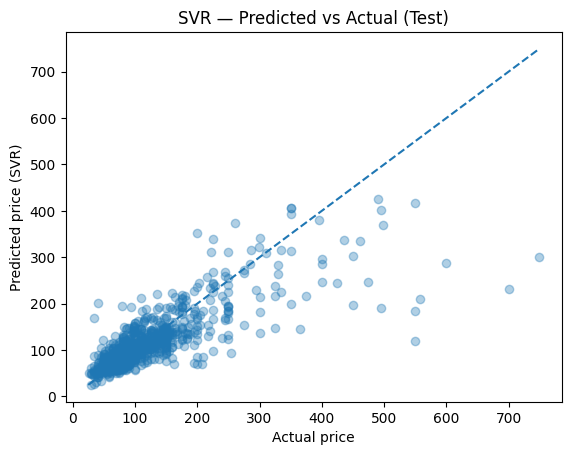

In [35]:
import matplotlib.pyplot as plt

p_te = best_svr.predict(X_test)
plt.scatter(y_test, p_te, alpha=0.35)
mn, mx = float(min(y_test.min(), p_te.min())), float(max(y_test.max(), p_te.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price (SVR)")
plt.title("SVR — Predicted vs Actual (Test)")
plt.show()
